# 02 Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare generative vs discriminative learning
- Choose the appropriate paradigm for a given task

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 01 "Regression vs Classification" — every model you have trained so far was discriminative; this lesson names the other option.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 01, which carries the same title and takes the comparison further.

---


## 🎯 A twenty-five-year-old result you are about to reproduce

In 2001 Andrew Ng and Michael Jordan published *On Discriminative vs. Generative
Classifiers: A Comparison of Logistic Regression and Naive Bayes* (reference 1
below) — exactly the pair you are about to run. Their result was not "one wins".
It was a **crossover**: naive Bayes (generative) has the higher asymptotic error
but approaches it much faster, so it wins when training data is scarce; logistic
regression (discriminative) is slower to converge and ends up better once there
is enough data. They demonstrated the crossing on fifteen datasets.

That paper is why "which one is better" is the wrong question and "how much
labelled data do I have" is the right one. On the 569 biopsies below, you are
sitting near the crossover, and the printed accuracies show it: **0.883** for
logistic regression against **0.877** for Gaussian naive Bayes. Six thousandths.
Halve the training set and the ordering can flip.

### What goes wrong if you only ever learn boundaries

Every model in this course so far has been discriminative: it learned where to
draw the line and nothing else. That is efficient and it forecloses several
things. A boundary cannot generate a new example, cannot say "this input is
unlike anything I was trained on", and cannot fill in a missing feature. The
generative model below can do all three — and you will see it do the first one,
sampling a new benign-looking biopsy that never existed.


# 02 Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the fundamental difference between generative and discriminative models
- Learn when to use each approach
- See practical examples of both types
- Understand the trade-offs between approaches

## 🔗 Prerequisites

- ✅ Understanding of machine learning basics
- ✅ Knowledge of classification concepts
- ✅ Basic Python knowledge

---

## Real-World Context

**Discriminative Models** (what we've learned):
- Email spam detection (classify spam vs not spam)
- Image classification (identify objects in images)
- Medical diagnosis (classify diseases)

**Generative Models** (new concept):
- Generate new emails that look like spam
- Create new images of objects
- Generate synthetic medical images for training

This notebook helps you understand when to use each approach!


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The real Breast Cancer Wisconsin (Diagnostic) dataset bundled with scikit-learn — 569 biopsies, no download

**Outputs:** What you'll see when you run the cells

- Held-out accuracy for both model families, the class distributions the generative model learned,
  one newly *sampled* biopsy, and a side-by-side plot of the two decision boundaries.

---

Example 2: Generative vs Discriminative Models

1. Fundamental Difference

DISCRIMINATIVE MODELS:
- Learn P(Y|X) - Probability of label given features
- Focus on decision boundary
- Directly model the conditional probability
- Examples: Logistic Regression, SVM, Neural Networks

GENERATIVE MODELS:
- Learn P(X|Y) and P(Y) - Joint probability distribution
- Model how data is generated
- Can generate new samples
- Examples: Naive Bayes, GANs, VAEs


2. Visual Comparison with Example Data
Real dataset: 569 biopsies, features ['mean radius', 'mean texture']
Classes: [212 357] (malignant, benign)

Test accuracy — discriminative (Logistic Regression): 0.883
Test accuracy — generative     (Gaussian Naive Bayes): 0.877

What the generative model learned about each class (mean of each feature):
  malignant: mean radius = 17.45 +/- 3.09, mean texture = 21.65 +/- 4.06
  benign   : mean radius = 12.11 +/- 1.75, mean texture = 17.98 +/- 4.17
  -> a NEW benign-looking biopsy sampled from that model: 

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_16964/584205632.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


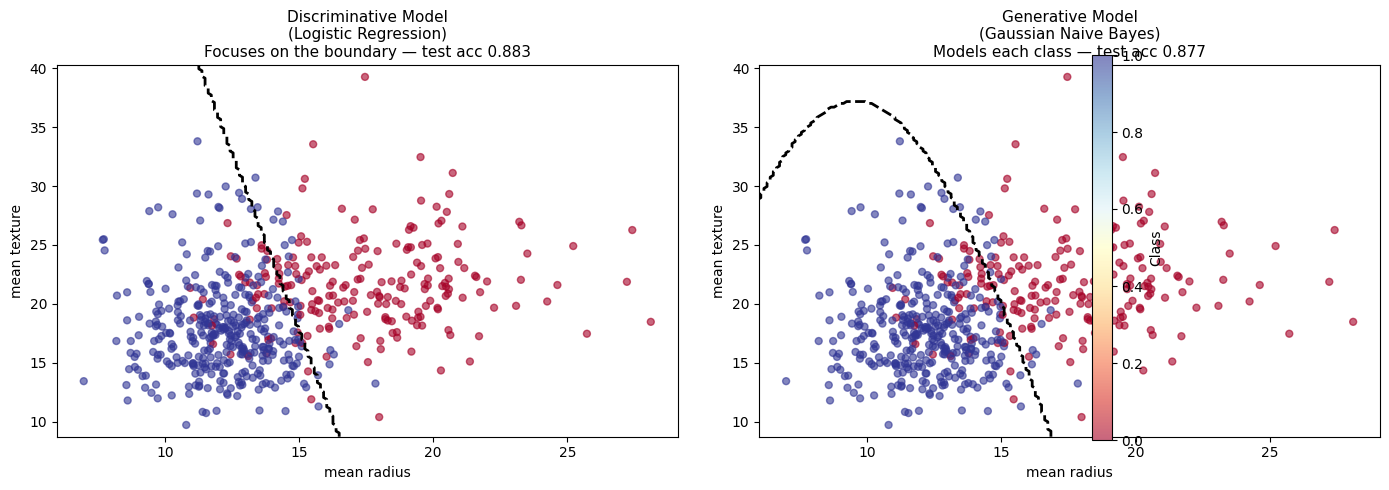


3. When to Use Each Approach

Use DISCRIMINATIVE when:
  • You only need classification/prediction
  • You have limited training data
  • You need fast inference
  • You want high accuracy for classification
  • Examples: Spam detection, image classification

Use GENERATIVE when:
  • You need to generate new data
  • You want to understand data distribution
  • You need to handle missing data
  • You want to detect outliers
  • Examples: Image generation, data augmentation, anomaly detection

4. Practical Example: Email Classification

Discriminative Approach:
  - Learns: P(Spam | email words)
  - Can classify: 'Is this email spam?'
  - Cannot generate: New spam emails

Generative Approach:
  - Learns: P(email words | Spam) and P(Spam)
  - Can classify: 'Is this email spam?'
  - Can generate: New spam emails that look realistic

5. Trade-offs Summary

Discriminative Models:
  Pros:
    + Often better classification accuracy
    + Faster training
    + Simpler models
  Cons:
    - Cann

In [1]:
# The core distinction of this unit made runnable: a discriminative model (logistic
# regression, learns P(y|x)) vs a generative one (naive Bayes, learns P(x|y)P(y)) on the same data.
# Their different worldviews show up directly in the decision boundaries we plot.
"""
Unit 5 - Example 2: Generative vs Discriminative Models

This example demonstrates:
1. Key differences between generative and discriminative models
2. When to use each approach
3. Practical examples
4. Trade-offs and considerations
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

print("=" * 70)
print("Example 2: Generative vs Discriminative Models")
print("=" * 70)

# 1. Fundamental Difference
print("\n" + "=" * 70)
print("1. Fundamental Difference")
print("=" * 70)

# The distinction in words: what each family models and what that buys you.
comparison = """
DISCRIMINATIVE MODELS:
- Learn P(Y|X) - Probability of label given features
- Focus on decision boundary
- Directly model the conditional probability
- Examples: Logistic Regression, SVM, Neural Networks

GENERATIVE MODELS:
- Learn P(X|Y) and P(Y) - Joint probability distribution
- Model how data is generated
- Can generate new samples
- Examples: Naive Bayes, GANs, VAEs
"""

print(comparison)

# 2. Visual Comparison
print("\n" + "=" * 70)
print("2. Visual Comparison with Example Data")
print("=" * 70)

# One shared REAL dataset so the two models can be compared apples to apples:
# 569 breast-tumour biopsies (Wisconsin Diagnostic, UCI), reduced to two of the
# 30 measured features so the decision boundaries can be drawn on paper.
cancer = load_breast_cancer()
pair = ["mean radius", "mean texture"]
cols = [list(cancer.feature_names).index(f) for f in pair]
X, y = cancer.data[:, cols], cancer.target      # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Real dataset: {X.shape[0]} biopsies, features {pair}")
print(f"Classes: {np.bincount(y)} (malignant, benign)")

# Train discriminative model (Logistic Regression): learns P(y|x) directly
discriminative_model = LogisticRegression(max_iter=1000)
discriminative_model.fit(X_train, y_train)

# Train generative model (Naive Bayes): learns P(x|y) and P(y), then applies Bayes' rule
generative_model = GaussianNB()
generative_model.fit(X_train, y_train)

# Score both on the SAME held-out biopsies — the comparison is only fair this way.
disc_acc = discriminative_model.score(X_test, y_test)
gen_acc = generative_model.score(X_test, y_test)
print(f"\nTest accuracy — discriminative (Logistic Regression): {disc_acc:.3f}")
print(f"Test accuracy — generative     (Gaussian Naive Bayes): {gen_acc:.3f}")

# What ONLY the generative model can do: describe how each class is distributed,
# and therefore invent a plausible new biopsy of a chosen class.
print("\nWhat the generative model learned about each class (mean of each feature):")
for cls, name in [(0, "malignant"), (1, "benign")]:
    mu = generative_model.theta_[cls]
    sd = np.sqrt(generative_model.var_[cls])
    print(f"  {name:9s}: {pair[0]} = {mu[0]:.2f} +/- {sd[0]:.2f}, "
          f"{pair[1]} = {mu[1]:.2f} +/- {sd[1]:.2f}")

sampler = np.random.default_rng(0)   # sampling from a fitted distribution IS the lesson here
fake_benign = sampler.normal(generative_model.theta_[1], np.sqrt(generative_model.var_[1]))
print(f"  -> a NEW benign-looking biopsy sampled from that model: "
      f"{pair[0]} = {fake_benign[0]:.2f}, {pair[1]} = {fake_benign[1]:.2f}")
print("  The logistic-regression model cannot do this: it never learned what a tumour")
print("  looks like, only where to draw the line between the two kinds.")

# Create decision boundary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot data
for ax in axes:
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', alpha=0.6, s=25)
    ax.set_xlabel(pair[0])
    ax.set_ylabel(pair[1])

# Discriminative model decision boundary
# Classify a dense grid with each model to draw the boundary each one learned.
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200))
Z_disc = discriminative_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_disc = Z_disc.reshape(xx.shape)
axes[0].contour(xx, yy, Z_disc, levels=[0.5], colors='black', linestyles='--', linewidths=2)
axes[0].set_title(f'Discriminative Model\n(Logistic Regression)\n'
                  f'Focuses on the boundary — test acc {disc_acc:.3f}', fontsize=11)

# Generative model decision boundary
Z_gen = generative_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_gen = Z_gen.reshape(xx.shape)
axes[1].contour(xx, yy, Z_gen, levels=[0.5], colors='black', linestyles='--', linewidths=2)
axes[1].set_title(f'Generative Model\n(Gaussian Naive Bayes)\n'
                  f'Models each class — test acc {gen_acc:.3f}', fontsize=11)

plt.colorbar(scatter, ax=axes, label='Class')
plt.tight_layout()
plt.show()

# 3. When to Use Each
print("\n" + "=" * 70)
print("3. When to Use Each Approach")
print("=" * 70)

# Practical guidance: when each family is the right tool.
use_cases = {
    "Use DISCRIMINATIVE when:": [
        "You only need classification/prediction", "You have limited training data",
        "You need fast inference",
        "You want high accuracy for classification",
        "Examples: Spam detection, image classification"
    ],
    "Use GENERATIVE when:": [
        "You need to generate new data",
        "You want to understand data distribution",
        "You need to handle missing data",
        "You want to detect outliers",
        "Examples: Image generation, data augmentation, anomaly detection"
    ]
}

for category, cases in use_cases.items():
    print(f"\n{category}")
    for case in cases:
        print(f"  • {case}")

# 4. Practical Example: Text Classification
print("\n" + "=" * 70)
print("4. Practical Example: Email Classification")
print("=" * 70)

example_emails = {
    "Spam": [
        "Win $1000 now! Click here!", "Free money! Limited time offer!",
        "Congratulations! You've won!"
    ],
    "Not Spam": [
        "Meeting scheduled for tomorrow",
        "Project update: Status report",
        "Team lunch this Friday"
    ]
}

print("\nDiscriminative Approach:")
print("  - Learns: P(Spam | email words)")
print("  - Can classify: 'Is this email spam?'")
print("  - Cannot generate: New spam emails")

print("\nGenerative Approach:")
print("  - Learns: P(email words | Spam) and P(Spam)")
print("  - Can classify: 'Is this email spam?'")
print("  - Can generate: New spam emails that look realistic")

# 5. Trade-offs
print("\n" + "=" * 70)
print("5. Trade-offs Summary")
print("=" * 70)

tradeoffs = {
    "Discriminative Models": {
        "Pros": ["Often better classification accuracy", "Faster training", "Simpler models"],
        "Cons": ["Cannot generate data", "Less interpretable", "Requires labeled data"]
    },
    "Generative Models": {
        "Pros": ["Can generate new data", "More interpretable", "Handles missing data"],
        "Cons": ["Often lower classification accuracy", "More complex", "Requires more data"]
    }
}

for model_type, aspects in tradeoffs.items():
    print(f"\n{model_type}:")
    print("  Pros:")
    for pro in aspects["Pros"]:
        print(f"    + {pro}")
    print("  Cons:")
    for con in aspects["Cons"]:
        print(f"    - {con}")

# 6. Summary
print("\n" + "=" * 70)
print("6. Key Takeaways")
print("=" * 70)

takeaways = [
    f"On these 2 real features the two scored {disc_acc:.3f} vs {gen_acc:.3f} on held-out biopsies",
    "Discriminative models focus on classification boundaries", "Generative models learn data distributions",
    "Choose based on your goal: classification vs generation",
    "Both approaches have their place in AI applications",
    "Modern AI often combines both approaches"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"{i}. {takeaway}")

print("\n" + "=" * 70)
print("Next: Diabetes classification with a feedforward network (notebook 03)")
print("=" * 70)

## 💬 Discuss

The printed results: logistic regression **0.883**, Gaussian naive Bayes
**0.877**; the generative model learned malignant tumours at mean radius
**17.45 ± 3.09** and benign at **12.11 ± 1.75**, then sampled a new "benign"
biopsy at radius **12.33**, texture **17.43**.

1. Six thousandths of accuracy separate the two models on 114 held-out biopsies —
   **less than one patient**. **On what grounds would you choose between them?**
   Make the argument without using accuracy at all, then say what evidence would
   override your choice.
2. The generative model produced a biopsy that no patient ever had. Suppose a
   hospital proposes sharing *synthetic* patient records instead of real ones, to
   protect privacy. **Does sampling from a fitted distribution actually protect
   the people in the training set?** Argue both sides — think about what the model
   memorised, and about rare patients whose values are far from any cluster.
3. Naive Bayes assumes `mean radius` and `mean texture` are independent given the
   diagnosis. Look at the two class summaries: is that plausible for tumour
   measurements? The model scored 0.877 anyway. **Explain how a false assumption
   can still support good decisions** — and predict the specific kind of output
   you should distrust because of it.


## ⚠️ Where this breaks

- **Naive Bayes' independence assumption is false here.** Tumour radius, texture,
  perimeter and area are all correlated. Because the model multiplies per-feature
  probabilities as if they were independent, it double-counts correlated evidence
  and produces **over-confident probabilities** — often 0.99 where 0.8 is
  warranted. Its *ranking* survives this; its *numbers* do not. Never quote a
  naive Bayes probability as a calibrated probability.
- **The 0.883 vs 0.877 gap is not a result.** On 114 test biopsies, that is a
  fraction of one patient and well inside the variation of a different random
  split. It illustrates the crossover; it does not locate it.
- **A generative model has to model everything about x.** With 2 features that is
  cheap. With images, text or 30 correlated clinical measurements, estimating the
  full distribution needs far more data than estimating a boundary — which is
  precisely why the asymptotic error of the discriminative model is lower.
- **Gaussian naive Bayes assumes each feature is normally distributed within each
  class.** For skewed or bounded measurements — fare prices, counts, durations —
  that assumption is wrong and the sampled "new" examples will be wrong in the
  same way, sometimes producing impossible values such as a negative measurement.
- **The sampled biopsy is not a patient.** It is a draw from two independent
  Gaussians. It has no correlation structure, no rare-disease tail, and no
  guarantee of being physiologically possible. Sampling realistically from a real
  distribution is the hard problem, and it is what the GAN in notebook 04 is about.
- **Only two of the thirty available features were used**, to keep the decision
  boundaries drawable. Both accuracies would move with the full feature set — and
  they would not move by the same amount, which is the point of the crossover.
- **When to use which:** discriminative when you have plenty of labels and only
  need the decision; generative when labels are scarce, when you need to detect
  inputs unlike the training data, when features go missing at prediction time, or
  when generating new samples is itself the product.


## 📚 References

1. Ng, A. Y., & Jordan, M. I. (2001). *On Discriminative vs. Generative Classifiers: A Comparison of Logistic Regression and Naive Bayes*. NeurIPS.
2. Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. <https://arxiv.org/abs/1406.2661>
3. Rombach, R., Blattmann, A., Lorenz, D., et al. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models* (Stable Diffusion). CVPR. <https://arxiv.org/abs/2112.10752>
4. Zhao, S., Zhang, X., Guo, J., et al. (2025). *Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities*. arXiv. <https://arxiv.org/abs/2505.02567>
5. Diao, H., Wu, P., Deng, H., et al. (2026). *SenseNova-U1: Unifying Multimodal Understanding and Generation with NEO-unify Architecture*. arXiv. <https://arxiv.org/abs/2605.12500>